# Dr. Case Notebook
# P2: Text Preprocessing with 20 Newsgroups

- Author: [Drew Schaffner](https://github.com/dsmorgancodes/)
- Repository: [nlp-02-text-preprocessing](https://github.com/dsmorgancodes/nlp-02-text-preprocessing/)
- Purpose: Demonstrate text preprocessing using a built-in scikit-learn dataset
- Date: 2026-03

## Section 1. Setup and Imports

Imports and configuration appear once at the top.

In [1]:
from pathlib import Path
import re
from typing import Any

import matplotlib.pyplot as plt
import polars as pl
from sklearn.datasets import (
    fetch_20newsgroups,  # pyright: ignore[reportMissingModuleSource]
)

print("Imports complete.")

Imports complete.


## Section 2. Load the Newsgroups Dataset

In [2]:
NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
DATA_PATH: Path = ROOT_PATH / "data"

categories: list[str] = [
    "sci.space",
    "rec.sport.baseball",
    "talk.politics.misc",
]

newsgroups: Any = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
)

text_list: list[str] = [
    " ".join(doc.split())
    for doc in newsgroups.data
    if isinstance(doc, str) and doc.strip()
]

print("Data loaded successfully.")
print(f"Loaded {len(text_list):,} text records.")

target_names: list[str] = list(newsgroups.target_names)
targets: list[int] = list(newsgroups.target)

category_df: pl.DataFrame = (
    pl.DataFrame({"target": targets})
    .with_columns(
        pl.col("target").replace_strict(dict(enumerate(target_names))).alias("category")
    )
    .group_by("category")
    .len()
    .sort("len", descending=True)
)

print("Records by category:")
print(category_df)

raw_text: str = " ".join(text_list)
print(f"Raw text length: {len(raw_text):,} characters")

Data loaded successfully.
Loaded 1,605 text records.
Records by category:
shape: (3, 2)
┌────────────────────┬─────┐
│ category           ┆ len │
│ ---                ┆ --- │
│ str                ┆ u64 │
╞════════════════════╪═════╡
│ rec.sport.baseball ┆ 597 │
│ sci.space          ┆ 593 │
│ talk.politics.misc ┆ 465 │
└────────────────────┴─────┘
Raw text length: 1,908,885 characters


## Section 3. Inspect the Raw Text

In [3]:
print("First 5 text records:")
for line in text_list[:5]:
    print("-", line[:160])

print(f"\nLoaded {len(text_list):,} text records.")
print(f"Raw text length: {len(raw_text):,} characters")
print("\nFirst 500 characters of combined text:")
print(raw_text[:500])

First 5 text records:
- Someone tell me there's a :-) hidden here somewhere... ??? -- ------------------------------------------------------------------------------- David Rex Wood -- 
- What suburban kid would want to hold down a minimum wage job when there is so much more money to be made dealing drugs? Yet, somehow, surburban kids do hold dow
- Who wants to look through the bars at some reactionary Liberal conspiracy- theory idiots and see how they rant and rave at the erosion of their populist support
- Would the sub-orbital version be suitable as-is (or "as-will-be") for use as a reuseable sounding rocket? Thank Ghod! I had thought that Spacelifter would defin
- So what does that have to do with RBI's? The team with the most RBI's doesn't necessarily win the game. Yes, runs are the most important statistice -- for a *te

Loaded 1,605 text records.
Raw text length: 1,908,885 characters

First 500 characters of combined text:
Someone tell me there's a :-) hidden here somewhere... ??

## Section 4. Tokenize the Raw Text

In [4]:
raw_tokens: list[str] = raw_text.split()
count_of_raw_tokens: int = len(raw_tokens)

print("First 20 raw tokens:")
print(raw_tokens[:20])
print(f"Total raw tokens: {count_of_raw_tokens:,}")

First 20 raw tokens:
['Someone', 'tell', 'me', "there's", 'a', ':-)', 'hidden', 'here', 'somewhere...', '???', '--', '-------------------------------------------------------------------------------', 'David', 'Rex', 'Wood', '--', 'davewood@cs.colorado.edu', '--', 'University', 'of']
Total raw tokens: 325,692


## Section 5. Normalize the Text

In [5]:
lower_text: str = raw_text.lower()
print("First 500 characters of lowercase text:")
print(lower_text[:500])

First 500 characters of lowercase text:
someone tell me there's a :-) hidden here somewhere... ??? -- ------------------------------------------------------------------------------- david rex wood -- davewood@cs.colorado.edu -- university of colorado at boulder what suburban kid would want to hold down a minimum wage job when there is so much more money to be made dealing drugs? yet, somehow, surburban kids do hold down minimum wage jobs. so do inner city kids, when give the chance. any reason you think that inner city kids are incapa


## Section 6. Remove Punctuation and Tokenize Again

In [6]:
no_punct_text: str = re.sub(r"[^a-z0-9\s]", " ", lower_text)
tokens_no_punct: list[str] = no_punct_text.split()
count_of_tokens_no_punct: int = len(tokens_no_punct)

print("First 20 tokens after lowercasing and punctuation removal:")
print(tokens_no_punct[:20])
print(f"Total tokens after punctuation removal: {count_of_tokens_no_punct:,}")

First 20 tokens after lowercasing and punctuation removal:
['someone', 'tell', 'me', 'there', 's', 'a', 'hidden', 'here', 'somewhere', 'david', 'rex', 'wood', 'davewood', 'cs', 'colorado', 'edu', 'university', 'of', 'colorado', 'at']
Total tokens after punctuation removal: 337,908


## Section 7. Remove Stop Words

In [7]:
STOP_WORDS: set[str] = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
}

clean_tokens: list[str] = [
    token for token in tokens_no_punct if len(token) > 2 and token not in STOP_WORDS
]

count_of_clean_tokens: int = len(clean_tokens)
vocab_reduction_pct: float = (
    (count_of_raw_tokens - count_of_clean_tokens) / count_of_raw_tokens * 100
    if count_of_raw_tokens > 0
    else 0.0
)

print("First 20 cleaned tokens:")
print(clean_tokens[:20])
print(f"Total cleaned tokens: {count_of_clean_tokens:,}")

First 20 cleaned tokens:
['someone', 'tell', 'there', 'hidden', 'here', 'somewhere', 'david', 'rex', 'wood', 'davewood', 'colorado', 'edu', 'university', 'colorado', 'boulder', 'what', 'suburban', 'kid', 'would', 'want']
Total cleaned tokens: 208,754


## Section 8. Build a Before/After Summary Table

In [8]:
summary_df: pl.DataFrame = pl.DataFrame(
    {
        "stage": [
            "raw tokens",
            "after punctuation removal",
            "after stop word removal",
        ],
        "count": [
            count_of_raw_tokens,
            count_of_tokens_no_punct,
            count_of_clean_tokens,
        ],
        "metric": [
            "",
            "",
            f"{vocab_reduction_pct:.1f}% reduction from raw",
        ],
    }
)

print("Preprocessing summary:")
print(summary_df)
print(f"Vocabulary reduction: {vocab_reduction_pct:.1f}%")

Preprocessing summary:
shape: (3, 3)
┌───────────────────────────┬────────┬──────────────────────────┐
│ stage                     ┆ count  ┆ metric                   │
│ ---                       ┆ ---    ┆ ---                      │
│ str                       ┆ i64    ┆ str                      │
╞═══════════════════════════╪════════╪══════════════════════════╡
│ raw tokens                ┆ 325692 ┆                          │
│ after punctuation removal ┆ 337908 ┆                          │
│ after stop word removal   ┆ 208754 ┆ 35.9% reduction from raw │
└───────────────────────────┴────────┴──────────────────────────┘
Vocabulary reduction: 35.9%


## Section 9. Build a Frequency Table with Polars

In [9]:
token_df: pl.DataFrame = pl.DataFrame({"token": clean_tokens})
freq_df: pl.DataFrame = token_df.group_by("token").len().sort("len", descending=True)

print("Top 20 most frequent cleaned tokens:")
print(freq_df.head(20))

Top 20 most frequent cleaned tokens:
shape: (20, 2)
┌────────┬──────┐
│ token  ┆ len  │
│ ---    ┆ ---  │
│ str    ┆ u64  │
╞════════╪══════╡
│ you    ┆ 2569 │
│ this   ┆ 2231 │
│ not    ┆ 1736 │
│ they   ┆ 1619 │
│ would  ┆ 1082 │
│ …      ┆ …    │
│ who    ┆ 733  │
│ people ┆ 699  │
│ think  ┆ 697  │
│ don    ┆ 690  │
│ his    ┆ 680  │
└────────┴──────┘


## Section 10. Build a Most Frequent Cleaned Tokens Bar Chart

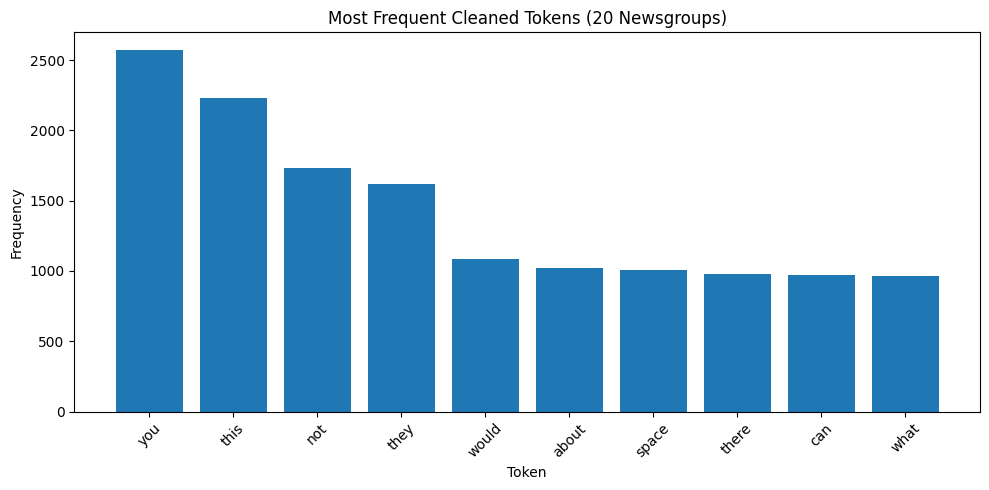

In [10]:
top_df: pl.DataFrame = freq_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_df["token"], top_df["len"])
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Cleaned Tokens (20 Newsgroups)")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 11. Compare Raw vs Clean Token Counts

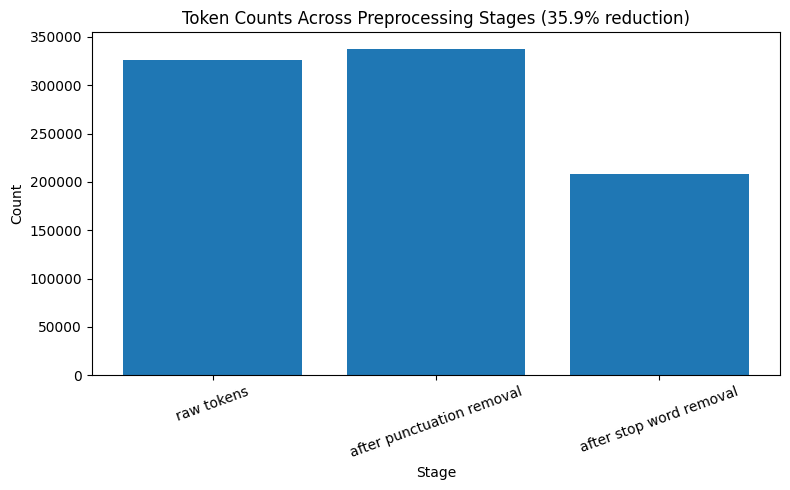

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["stage"], summary_df["count"])
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title(
    f"Token Counts Across Preprocessing Stages ({vocab_reduction_pct:.1f}% reduction)"
)
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()